<a href="https://colab.research.google.com/github/jhongarciaalcaraz961-droid/-Phase_4_-203018207_1_Jhon_Garcia/blob/main/Predictive_HVAC_(Heating%2C_Ventilation%2C_and_Air_Conditioning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 5 - Presentation of results and evaluation

**Student**

                         Jhon Jairo Garcia Alcaraz

                            Group: 203018207_1

**Instructor**

                       Maria Alejandra Varona Taborda

**Course**

                      (203018207A_2202) – Data Analytics

                Universidad Nacional Abierta y a Distancia UNAD

                   Specialization in Telecommunications Networks

                                 July 2026

# Context
This dataset is collected from 255 sensor time series, instrumented in 51 rooms in 4 floors of the Sutardja Dai Hall(SDH) at UC Berkeley. It can be used to investigate patterns in physical properties of a room in a building. Moreover, it can also be used for experiments relating to Internet-of-Things (IoT), sensor fusion network or time-series tasks. This dataset is suitable for both supervised (classification and regression) and unsupervised learning (clustering) tasks.

# Content
Each room includes 5 types of measurements: CO2 concentration, room air humidity, room temperature, luminosity, and PIR motion sensor data, collected over a period of one week from Friday, August 23, 2013 to Saturday, August 31, 2013. The PIR motion sensor is sampled once every 10 seconds and the remaining sensors are sampled once every 5 seconds. Each file contains the timestamps (in Unix Epoch Time) and actual readings from the sensor.

The passive infrared sensor (PIR sensor) is an electronic sensor that measures infrared (IR) light radiating from objects in its field of view, which measures the occupancy in a room. Approximately 6% of the PIR data is non-zero, indicating an occupied status of the room. The remaining 94% of the PIR data is zero, indicating an empty room.

# Predictive HVAC (Heating, Ventilation, and Air Conditioning)


1. Import Library

2. Data Preparation

3. Data division

4. Model Learning

5. Model Evaluation

6. Save the model

# 1. Import Library

In [15]:
# ==============================================================================
# SISTEMA PREDICTIVO DE CALIDAD DEL AIRE - MULTI-PISO (EDIFICIO SDH)
# ==============================================================================

# 1. IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------------------------
import os  # Permite navegar e interactuar con el sistema de archivos del sistema
from pathlib import Path  # Facilita la manipulación orientada a objetos de rutas de archivos
import glob  # Búsqueda avanzada de patrones de nombres de archivos
import zipfile  # Librería nativa para manipular archivos comprimidos .zip
import pandas as pd  # Librería principal para manipulación y limpieza de estructuras de datos
import numpy as np  # Operaciones matemáticas y manejo de matrices moleculares
import matplotlib.pyplot as plt  # Creación de gráficos básicos y lienzos
import seaborn as sns  # Visualizaciones estadísticas avanzadas y estilizadas
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Algoritmo de clasificación predictiva
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Configuración de apariencia visual para los gráficos de análisis de patrones
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías del ecosistema de Ciencia de Datos inicializadas para evaluación tri-modal.")



✅ Librerías del ecosistema de Ciencia de Datos inicializadas para evaluación tri-modal.


# 2. Data Preparation

In [6]:
# ==============================================================================
# ETAPA 2: DATA PREPARATION (CARGA, LIMPIEZA E INGENIERÍA DE CARACTERÍSTICAS)
# ==============================================================================

# Buscamos en el directorio actual (/content/) cualquier archivo que termine en .zip
archivos_zip_encontrados = glob.glob("*.zip")
CARPETA_DESTINO = "datos_extraidos_sdh"

if len(archivos_zip_encontrados) == 0:
    print("❌ ERROR: No se encontró ningún archivo .zip en la barra lateral de Colab.")
    print("Por favor, arrastra tu archivo comprimido a la sección de archivos (índice de carpeta a la izquierda).")
else:
    # Seleccionamos el primer archivo .zip que encuentre el sistema
    ARCHIVO_ZIP = archivos_zip_encontrados[0]
    print(f"📦 Se detectó el archivo: '{ARCHIVO_ZIP}'")
    print(f"⏳ Descomprimiendo en la carpeta '{CARPETA_DESTINO}'...")

    # Extraer el contenido manteniendo la estructura jerárquica interna
    with zipfile.ZipFile(ARCHIVO_ZIP, 'r') as zip_ref:
        zip_ref.extractall(CARPETA_DESTINO)
    print("🔓 ¡Descompresión completada con éxito!")



📦 Se detectó el archivo: 'sensores_data.zip'
⏳ Descomprimiendo en la carpeta 'datos_extraidos_sdh'...
🔓 ¡Descompresión completada con éxito!


In [7]:
# ==============================================================================
# CONSOLIDACIÓN SENSOR-TEMPORAL (DATA PREPARATION)
# ==============================================================================

def consolidar_datos_edificio(ruta_origen):
    """Recorre las subcarpetas del ZIP desempacado, alinea y limpia los sensores."""
    lista_habitaciones = []
    ruta_base = Path(ruta_origen)

    # Escaneamos recursivamente buscando los archivos de co2 para mapear las habitaciones
    archivos_co2 = list(ruta_base.rglob("co2.csv"))

    if not archivos_co2:
        print("⚠️ No se encontraron archivos 'co2.csv' dentro del ZIP. Verifica la estructura interna.")
        return None

    for ruta_co2 in archivos_co2:
        carpeta_habitacion = ruta_co2.parent
        nombre_habitacion = carpeta_habitacion.name
        nombre_piso = carpeta_habitacion.parent.name

        # Estructura estándar de los sensores por cada sala instrumentada
        diccionario_sensores = {
            'co2.csv': 'CO2',
            'humidity.csv': 'Humedad',
            'light.csv': 'Luz',
            'temperature.csv': 'Temperatura',
            'pir.csv': 'PIR'
        }

        df_habitacion = None

        for archivo, columna in diccionario_sensores.items():
            ruta_sensor = carpeta_habitacion / archivo
            if ruta_sensor.exists():
                # Carga de la serie temporal (Columna 0: Timestamp Unix, Columna 1: Medición)
                df_s = pd.read_csv(ruta_sensor, names=['timestamp', columna])
                df_s['fecha_hora'] = pd.to_datetime(df_s['timestamp'], unit='s')
                df_s.set_index('fecha_hora', inplace=True)
                df_s.drop(columns=['timestamp'], inplace=True)

                # Remuestreo cada 5 minutos para resolver la asincronía de la red IoT
                if columna == 'PIR':
                    df_res = df_s.resample('5min').max()  # Determina si hubo movimiento en la ventana
                else:
                    df_res = df_s.resample('5min').mean() # Promedio continuo

                if df_habitacion is None:
                    df_habitacion = df_res
                else:
                    df_habitacion = df_habitacion.join(df_res, how='outer')

        if df_habitacion is not None:
            # Rellenar vacíos mediante interpolación en el tiempo por cada habitación
            df_habitacion = df_habitacion.interpolate(method='time')
            df_habitacion['PIR'] = df_habitacion['PIR'].fillna(0)  # Vacío en PIR representa sin movimiento

            # Almacenar variables contextuales del espacio físico
            df_habitacion['Piso'] = nombre_piso
            df_habitacion['Habitacion'] = nombre_habitacion
            lista_habitaciones.append(df_habitacion)

    if lista_habitaciones:
        df_maestro = pd.concat(lista_habitaciones, axis=0)
        # Asegurar la limpieza de nulos marginales en los extremos
        df_maestro.dropna(subset=['CO2', 'Temperatura', 'Humedad', 'Luz'], inplace=True)
        return df_maestro
    return None

# Validar que la carpeta de descompresión exista antes de procesar
if os.path.exists(CARPETA_DESTINO):
    df_edificio = consolidar_datos_edificio(CARPETA_DESTINO)
    if df_edificio is not None:
        print(f"\n📊 Dataset maestro consolidado.")
        print(f"   • Muestras espacio-temporales totales: {df_edificio.shape[0]}")
        print(df_edificio.head())




📊 Dataset maestro consolidado.
   • Muestras espacio-temporales totales: 120439
                            CO2    Humedad       Luz  Temperatura  PIR  \
fecha_hora                                                               
2013-08-23 23:00:00  426.000000  43.090000  6.000000    25.850000  0.0   
2013-08-23 23:05:00  433.909091  43.141250  5.339286    25.831607  0.0   
2013-08-23 23:10:00  441.200000  43.233500  5.216667    25.793833  0.0   
2013-08-23 23:15:00  444.333333  43.325833  5.383333    25.763000  0.0   
2013-08-23 23:20:00  451.650000  43.390833  5.250000    25.736333  0.0   

                              Piso Habitacion  
fecha_hora                                     
2013-08-23 23:00:00  sensores_data        752  
2013-08-23 23:05:00  sensores_data        752  
2013-08-23 23:10:00  sensores_data        752  
2013-08-23 23:15:00  sensores_data        752  
2013-08-23 23:20:00  sensores_data        752  


In [10]:
# ------------------------------------------------------------------------------
# INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# ------------------------------------------------------------------------------
print("⏳ Corrigiendo información espacial y generando variables temporales...")

# Convertimos la columna 'Habitacion' a cadena de texto para poder manipular sus dígitos
df_edificio['Habitacion'] = df_edificio['Habitacion'].astype(str)

# Extraemos el primer carácter numérico que representa el Piso Real (Ej: '417' -> 4)
df_edificio['Piso_Real'] = df_edificio['Habitacion'].str[0].astype(int)

# Extraemos características temporales cíclicas a partir del índice cronológico (fecha_hora)
df_edificio['Hora'] = df_edificio.index.hour
df_edificio['Dia_Semana'] = df_edificio.index.dayofweek
df_edificio['Es_Fin_De_Semana'] = (df_edificio['Dia_Semana'] >= 5).astype(int)

print("✅ Ingeniería de variables espaciotemporales completada.")


⏳ Corrigiendo información espacial y generando variables temporales...
✅ Ingeniería de variables espaciotemporales completada.


In [11]:
# ==============================================================================
# PREPARACIÓN DE DATOS Y DEFINICIÓN DEL OBJETIVO CRÍTICO
# ==============================================================================
# Según estándares internacionales de calidad del aire (ASHRAE), niveles superiores
# a 475-500 ppm en entornos cerrados base reflejan acumulación de ocupantes o fallas de ventilación.
UMBRAL_CRITICO = 475

# Definimos la variable objetivo (Target): 1 = Estado Crítico (Ventilar), 0 = Normal
df_edificio['Situacion_Critica'] = (df_edificio['CO2'] > UMBRAL_CRITICO).astype(int)

# Seleccionamos las variables predictoras (Features) excluyendo las mediciones directas de CO2
caracteristicas_X = ['Humedad', 'Luz', 'Temperatura', 'PIR', 'Piso_Real', 'Hora', 'Es_Fin_De_Semana']
X = df_edificio[caracteristicas_X]
y = df_edificio['Situacion_Critica']


📈 Generando visualizaciones del contexto del problema...


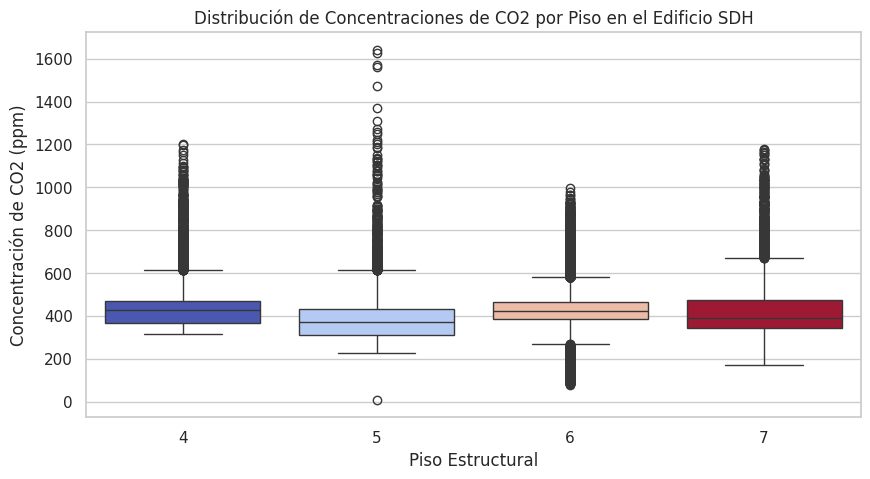

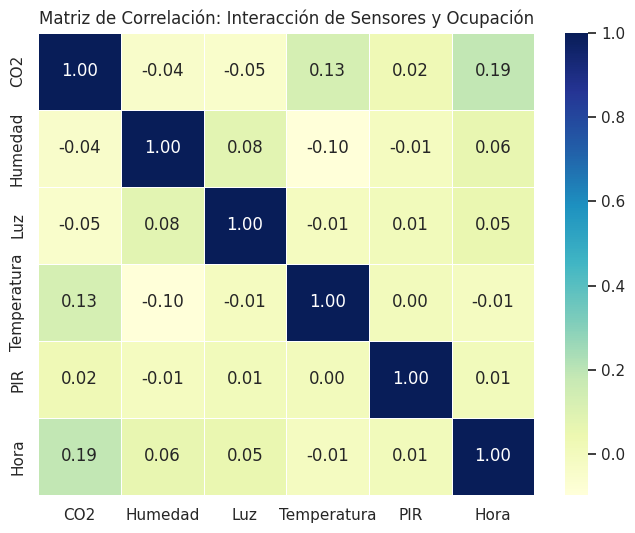

In [12]:
# ==============================================================================
# ANÁLISIS EXPLORATORIO Y ENCONTRAR PATRONES INICIALES (VISUALIZACIONES)
# ==============================================================================
print("\n📈 Generando visualizaciones del contexto del problema...")

# Gráfica 1: Comportamiento del CO2 por Piso Real
plt.figure(figsize=(10, 5))
sns.boxplot(x='Piso_Real', y='CO2', data=df_edificio, hue='Piso_Real', palette='coolwarm', legend=False)
plt.title('Distribución de Concentraciones de CO2 por Piso en el Edificio SDH')
plt.xlabel('Piso Estructural')
plt.ylabel('Concentración de CO2 (ppm)')
plt.show()

# Gráfica 2: Matriz de Correlación de Variables Físicas e IoT
plt.figure(figsize=(8, 6))
columnas_interes = ['CO2', 'Humedad', 'Luz', 'Temperatura', 'PIR', 'Hora']
sns.heatmap(df_edificio[columnas_interes].corr(), annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación: Interacción de Sensores y Ocupación')
plt.show()

# 3. Data Division

In [13]:
# ==============================================================================
# DIVISIÓN CRONOLÓGICA DE DATOS (Manejo Estricto de Series Temporales)
# ==============================================================================
# Ordenamos el dataset por tiempo antes de cortar para evitar la fuga de datos (Data Leakage)
X = X.sort_index()
y = y.sort_index()

# 80% para entrenamiento (Aprender del pasado) y 20% para validación (Predecir el futuro)
indice_corte = int(len(X) * 0.8)

X_train, X_test = X.iloc[:indice_corte], X.iloc[indice_corte:]
y_train, y_test = y.iloc[:indice_corte], y.iloc[indice_corte:]

# Escalado estándar (Mandatorio para Regresión Logística y estabilidad de gradientes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n📂 Distribución temporal completada de las {len(df_edificio)} muestras:")
print(f"   • Entrenamiento (Pasado): {X_train.shape[0]} registros")
print(f"   • Validación (Futuro): {X_test.shape[0]} registros")


📂 Distribución temporal completada de las 120439 muestras:
   • Entrenamiento (Pasado): 96351 registros
   • Validación (Futuro): 24088 registros


# 4. Model Learning

In [16]:
# ==============================================================================
# ETAPA 4: MODEL LEARNING (ENTRENAMIENTO SIMULTÁNEO)
# ==============================================================================
print("🤖 Entrenando Modelo 1: Random Forest Classifier...")
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

print("🤖 Entrenando Modelo 2: Regresión Logística...")
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

print("🤖 Entrenando Modelo 3: Gradient Boosting Classifier...")
modelo_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
modelo_gb.fit(X_train, y_train)

print("🎯 ¡Los tres arquitecturas predictivas han sido entrenadas!")

🤖 Entrenando Modelo 1: Random Forest Classifier...
🤖 Entrenando Modelo 2: Regresión Logística...
🤖 Entrenando Modelo 3: Gradient Boosting Classifier...
🎯 ¡Los tres arquitecturas predictivas han sido entrenadas!


# 5. Model Evaluations


📊 === REPORTE MODELO 1: RANDOM FOREST ===
              precision    recall  f1-score   support

      Óptimo       0.88      0.96      0.91     18771
     Crítico       0.77      0.52      0.62      5317

    accuracy                           0.86     24088
   macro avg       0.82      0.74      0.77     24088
weighted avg       0.85      0.86      0.85     24088


📊 === REPORTE MODELO 2: REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

      Óptimo       0.80      1.00      0.89     18771
     Crítico       0.88      0.12      0.21      5317

    accuracy                           0.80     24088
   macro avg       0.84      0.56      0.55     24088
weighted avg       0.82      0.80      0.74     24088


📊 === REPORTE MODELO 3: GRADIENT BOOSTING ===
              precision    recall  f1-score   support

      Óptimo       0.88      0.95      0.91     18771
     Crítico       0.75      0.54      0.63      5317

    accuracy                           0.86

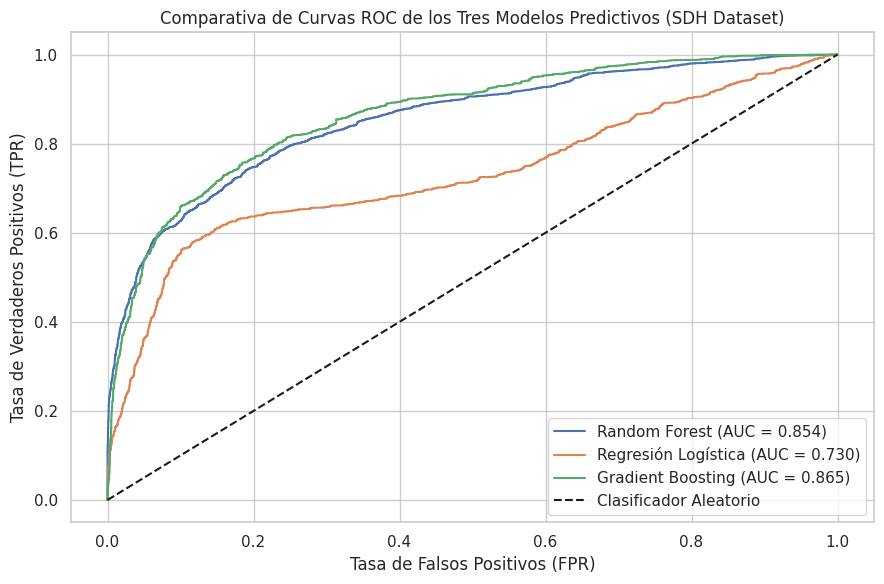

In [17]:
# ==============================================================================
# ETAPA 5: MODEL EVALUATION (MÉTRICAS CRUZADAS Y ANÁLISIS ROC/AUC)
# ==============================================================================
y_pred_rf = modelo_rf.predict(X_test)
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_pred_gb = modelo_gb.predict(X_test)

print("\n📊 === REPORTE MODELO 1: RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=['Óptimo', 'Crítico']))

print("\n📊 === REPORTE MODELO 2: REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr, target_names=['Óptimo', 'Crítico']))

print("\n📊 === REPORTE MODELO 3: GRADIENT BOOSTING ===")
print(classification_report(y_test, y_pred_gb, target_names=['Óptimo', 'Crítico']))

# Análisis Gráfico Comparativo: Curvas ROC
plt.figure(figsize=(9, 6))
modelos_eval = [
    (modelo_rf, 'Random Forest', X_test),
    (modelo_lr, 'Regresión Logística', X_test_scaled),
    (modelo_gb, 'Gradient Boosting', X_test)
]

for mod, name, X_t in modelos_eval:
    probs = mod.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparativa de Curvas ROC de los Tres Modelos Predictivos (SDH Dataset)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()